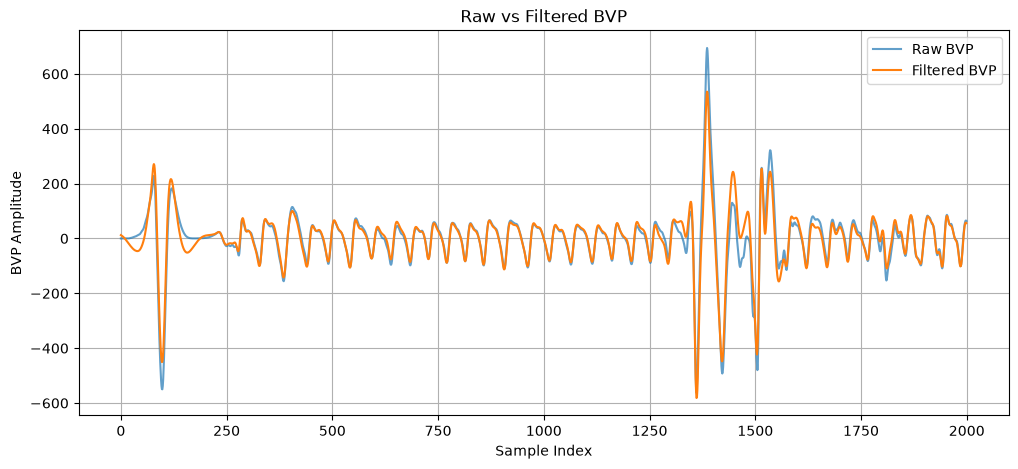

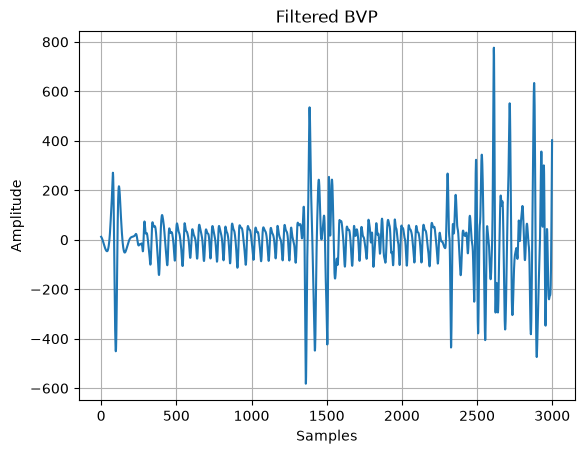

           Metric           Raw      Filtered
0            Mean      0.003597      0.000225
1             Std     82.681627     70.299440
2    Spikes (>3σ)  13689.000000  13742.000000
3  Noise Estimate     12.788661     11.561297
4      Peak Count   9719.000000   9548.000000
Min (Raw): -893.83
Max (Raw): 1254.48
Min (Filtered): -927.0705152829884
Max (Filtered): 1060.67083372521


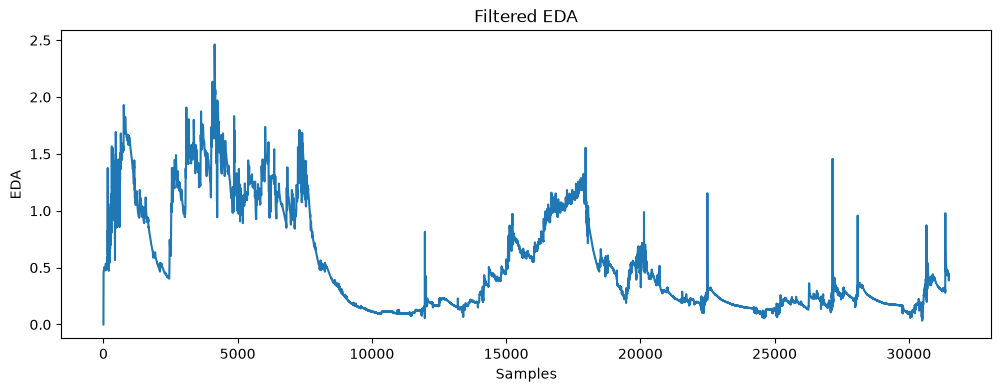

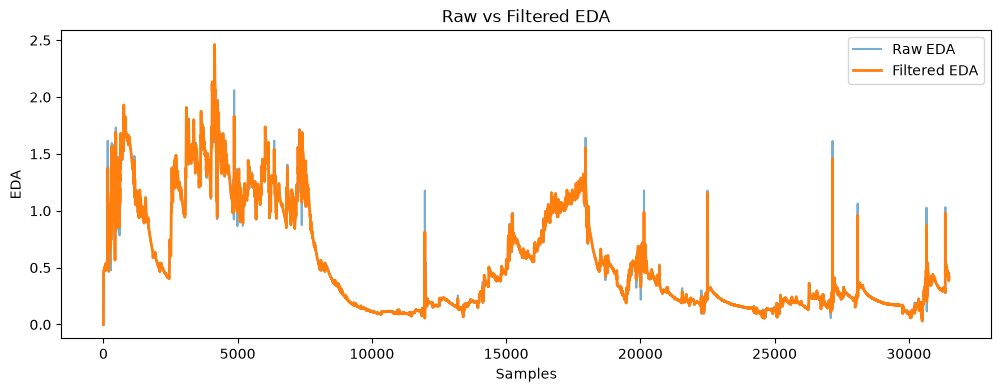

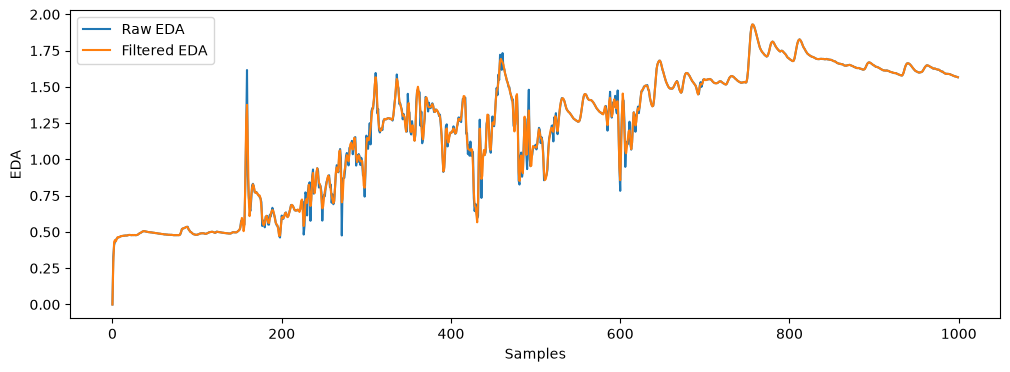

========== RAW EDA ==========
Samples   : 31494
Mean      : 0.5478223880104146
Std       : 0.46081414615229327
Noise     : 0.024727757661578493
Spikes    : 430
Peaks     : 753
Drift     : -3.201999789040936e-05

========== FILTERED EDA ==========
Samples   : 31494
Mean      : 0.5478219366606292
Std       : 0.4606991855891192
Noise     : 0.017869333467055756
Spikes    : 499
Peaks     : 576
Drift     : -3.2019884318070166e-05
========== RAW HR ==========
Mean      : 75.09649459631277
Std       : 10.736697505251097
Spikes    : 224
Noise     : 0.3000398582891357
Drift     : -0.0011579986425533176

========== FILTERED HR ==========
Mean      : 75.09649217195201
Std       : 10.736027595230649
Spikes    : 223
Noise     : 0.2690668136252866
Drift     : -0.0011579963662164282

========== IMPROVEMENT ==========
Noise Reduction (%) : 10.322976700649447
Std Reduction (%) : 0.006239442064200317


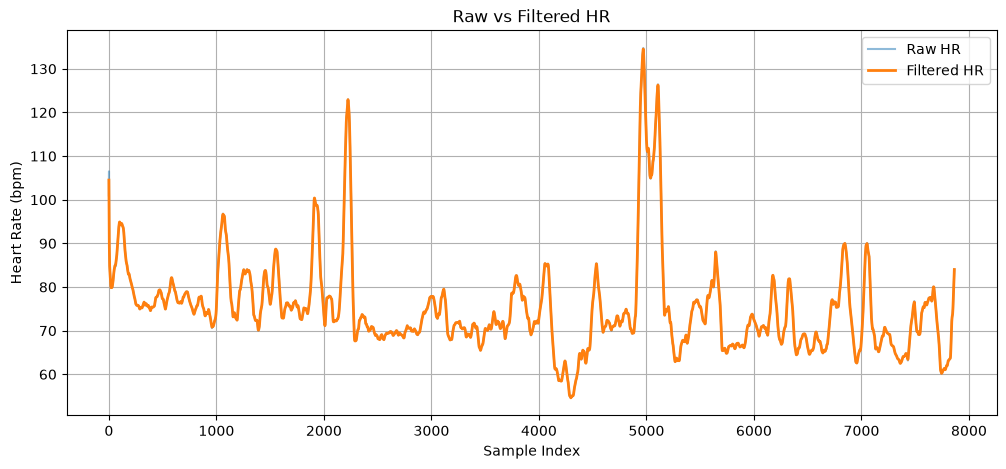


===== IBI QUALITY METRICS =====

Mean IBI       | Raw: 0.854326 | Filtered: 0.854118
Std IBI        | Raw: 0.089570 | Filtered: 0.074614
Outliers       | Raw: 12 | Filtered: 3
Noise          | Raw: 0.077135 | Filtered: 0.028177
Smoothness     | Raw: 0.056419 | Filtered: 0.016042
Consistency    | Raw: 0.104843 | Filtered: 0.087358


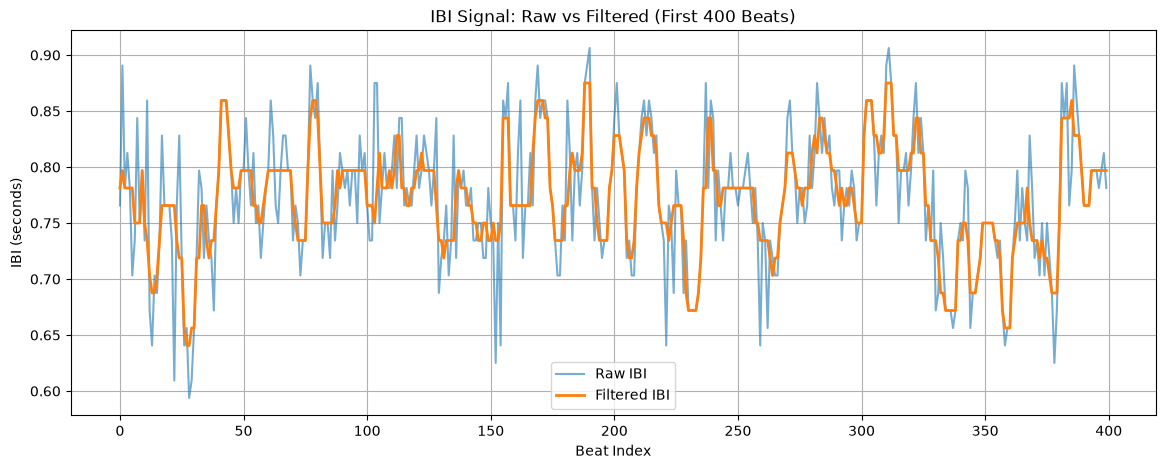

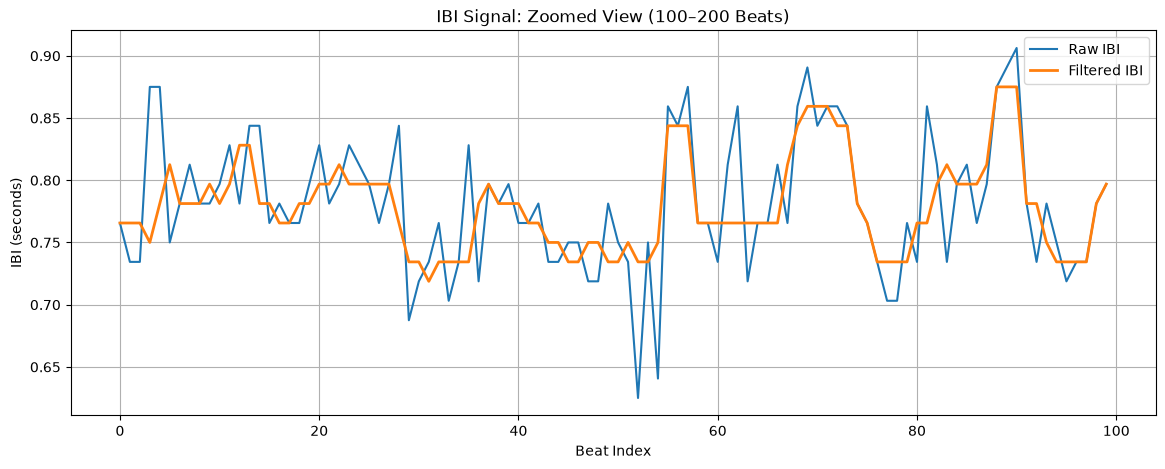


===== TEMPERATURE METRICS =====

Mean       | Raw: 34.569947 | Filtered: 34.569947
Std        | Raw: 1.014630 | Filtered: 1.014605
Min        | Raw: 32.310000 | Filtered: 32.311745
Max        | Raw: 35.970000 | Filtered: 35.967632
Range      | Raw: 3.660000 | Filtered: 3.655887
Noise      | Raw: 0.009895 | Filtered: 0.004522
Drift      | Raw: -0.000073 | Filtered: -0.000073

===== PERCENT CHANGE =====

Mean      : -0.00%
Std       : -0.00%
Min       : 0.01%
Max       : -0.01%
Range     : -0.11%
Noise     : -54.30%
Drift     : 0.00%


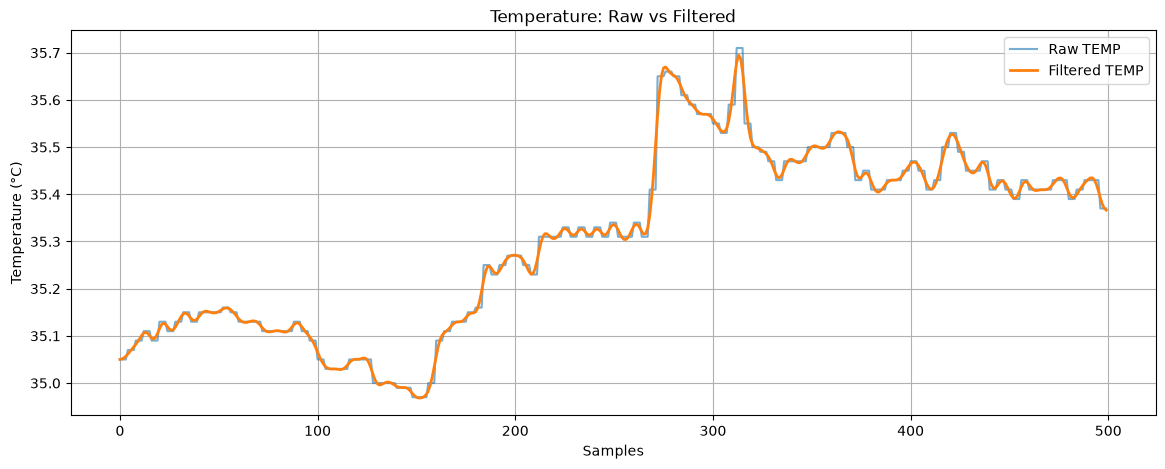

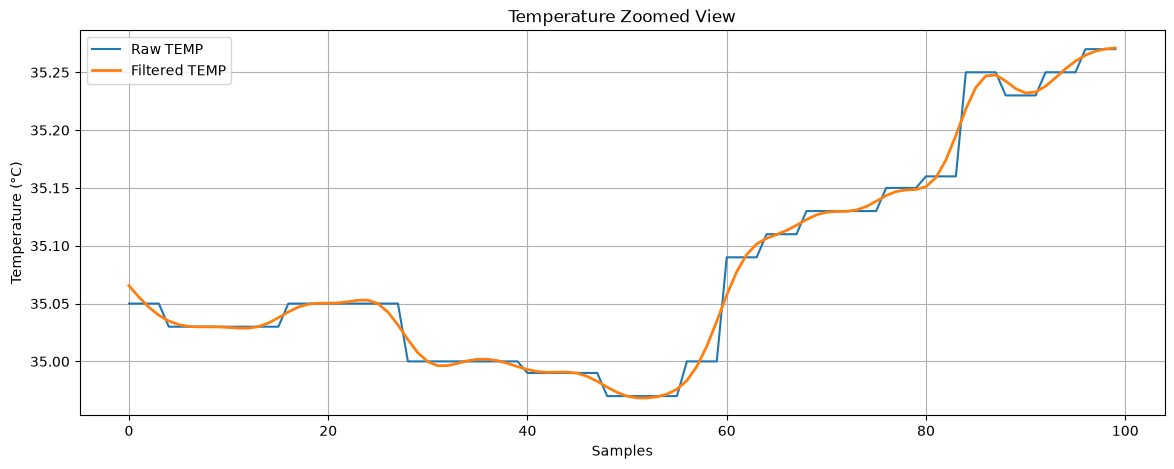

In [ ]:
%run 01_filtering.ipynb

In [ ]:
from normalize_signals import normalize_all

signals_to_normalize = {
    # Empatica
    'EDA_E4':  eda_filtered,
    'BVP_E4':  bvp_filtered,
    'HR_E4':   hr_filtered,
    'TEMP_E4': filtered_temp,

    # RespiBAN
    'ECG_RB':  ecg_filtered,
    'EDA_RB':  EDA_filtered,
    'EMG_RB':  emg_centered,
    'RESP_RB': RESPIRATION_filtered,
    'TEMP_RB': temp_filtered,
}

normalized_data = normalize_all(signals_to_normalize, method='zscore')

# quick check
for name, arr in normalized_data.items():
    print(name, 'mean=', round(arr.mean(), 3), 'std=', round(arr.std(), 3))

In [ ]:
import pandas as pd

for name, arr in normalized_data.items():
    pd.DataFrame({name: arr}).to_csv(f'normalized_{name}.csv', index=False)

In [ ]:
ibi_values = ibi_filtered['IBI'].values   # adjust column name to match your DataFrame
ibi_norm = normalize_all({'IBI': ibi_values})['IBI']

In [1]:
!pip install nbformat nbclient jupyter_client

Defaulting to user installation because normal site-packages is not writeable
  Using cached nbclient-0.11.0-py3-none-any.whl.metadata (7.3 kB)
Using cached nbclient-0.11.0-py3-none-any.whl (25 kB)
